In [2]:
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc

import ufl
from ufl import div, dx, inner, FiniteElement, FacetNormal

import dolfinx
import dolfinx.fem.petsc                     # explicit import required in v0.6.0
from dolfinx import fem
from dolfinx.fem import (
    Function, FunctionSpace, dirichletbc, form,
    locate_dofs_topological,
)
from dolfinx.mesh import (
    create_rectangle, CellType, GhostMode, locate_entities_boundary,
)

# ---------------------------------------------------------------------------
# 1.  Mesh
# ---------------------------------------------------------------------------
comm = MPI.COMM_WORLD

Nx, Ny = 32, 32
domain = create_rectangle(
    comm,
    [np.array([0.0, 0.0]), np.array([1.0, 1.0])],
    [Nx, Ny],
    CellType.triangle,
    GhostMode.none,
)

tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)

# ---------------------------------------------------------------------------
# 2.  Mark boundary facets
# ---------------------------------------------------------------------------
tol = 1e-12
x_in_lo,  x_in_hi  = 0.2, 0.5    # inflow  x-extent on y=0
x_out_lo, x_out_hi = 0.6, 0.9    # outflow x-extent on y=0

def inflow_facets(x):
    return (
        np.isclose(x[1], 0.0, atol=tol) &
        (x[0] >= x_in_lo  - tol) & (x[0] <= x_in_hi  + tol)
    )

def outflow_facets(x):
    return (
        np.isclose(x[1], 0.0, atol=tol) &
        (x[0] >= x_out_lo - tol) & (x[0] <= x_out_hi + tol)
    )

inflow_facet_ids  = locate_entities_boundary(domain, fdim, inflow_facets)
outflow_facet_ids = locate_entities_boundary(domain, fdim, outflow_facets)

# ---------------------------------------------------------------------------
# 3.  Function spaces  (v0.6.0: ufl.FiniteElement + FunctionSpace)
# ---------------------------------------------------------------------------
cell = domain.ufl_cell()

BDM1 = FiniteElement("BDM", cell, 1)   # H(div)-conforming, vector-valued
DG0  = FiniteElement("DG",  cell, 0)   # piecewise constant

V = FunctionSpace(domain, BDM1)
Q = FunctionSpace(domain, DG0)

# ---------------------------------------------------------------------------
# 4.  Heterogeneous permeability  K(x,y) = k(x,y) * I
# ---------------------------------------------------------------------------
k_func = Function(FunctionSpace(domain, DG0))

def k_expression(x):
    # Gaussian high-permeability inclusion at centre; background k=1
    return 1.0 + 9.0 * np.exp(-((x[0] - 0.5)**2 + (x[1] - 0.5)**2) / 0.04)

k_func.interpolate(k_expression)

zero = fem.Constant(domain, PETSc.ScalarType(0.0))
K_inv = ufl.as_matrix([
    [1.0 / k_func, zero         ],
    [zero,         1.0 / k_func ],
])

# ---------------------------------------------------------------------------
# 5.  Blocked variational forms
# ---------------------------------------------------------------------------
u, p = ufl.TrialFunction(V), ufl.TrialFunction(Q)
v, q = ufl.TestFunction(V),  ufl.TestFunction(Q)

f      = fem.Constant(domain, PETSc.ScalarType(0.0))
zero_v = fem.Constant(domain, (PETSc.ScalarType(0.0), PETSc.ScalarType(0.0)))

a = form([
    [inner(K_inv * u, v) * dx,  -inner(p, div(v)) * dx],
    [inner(div(u), q)   * dx,    None                  ],
])

L = form([
    inner(zero_v, v) * dx,
    inner(f, q)      * dx,
])

# ---------------------------------------------------------------------------
# 6.  Essential BCs: inflow and outflow normal fluxes
# ---------------------------------------------------------------------------
# Bottom boundary outward normal: n = (0, -1)
# u.n = g  =>  u = (0, -g) on those facets
#
# g_in_val  = -1.0  (inflow:  u.n < 0, into domain)
# g_out_val = +1.0  (outflow: u.n > 0, out of domain)

g_in_val  = PETSc.ScalarType(-1.0)
g_out_val = PETSc.ScalarType(+1.0)

u_bc_in  = Function(V)
u_bc_out = Function(V)

u_bc_in.interpolate(lambda x: np.vstack([
    np.zeros(x.shape[1]),
    np.full(x.shape[1], -g_in_val),
]))

u_bc_out.interpolate(lambda x: np.vstack([
    np.zeros(x.shape[1]),
    np.full(x.shape[1], -g_out_val),
]))

dofs_in  = locate_dofs_topological(V, fdim, inflow_facet_ids)
dofs_out = locate_dofs_topological(V, fdim, outflow_facet_ids)

# v0.6.0: dirichletbc(Function, dofs) -- no third V argument for top-level spaces
bc_in  = dirichletbc(u_bc_in,  dofs_in)
bc_out = dirichletbc(u_bc_out, dofs_out)

bcs = [bc_in, bc_out]

# ---------------------------------------------------------------------------
# 7.  Assemble and solve
# ---------------------------------------------------------------------------
A = dolfinx.fem.petsc.assemble_matrix_block(a, bcs=bcs)
A.assemble()

b = dolfinx.fem.petsc.assemble_vector_block(L, a, bcs=bcs)

x = A.createVecRight()

ksp = PETSc.KSP().create(comm)
ksp.setOperators(A)
ksp.setType("preonly")
ksp.getPC().setType("lu")
ksp.getPC().setFactorSolverType("mumps")
ksp.setFromOptions()
ksp.solve(b, x)

if comm.rank == 0:
    print(f"KSP converged reason: {ksp.getConvergedReason()}")

# ---------------------------------------------------------------------------
# 8.  Split blocked solution into velocity and pressure Functions
# ---------------------------------------------------------------------------
offset_u = V.dofmap.index_map.size_local * V.dofmap.index_map_bs
offset_p = Q.dofmap.index_map.size_local * Q.dofmap.index_map_bs

uh = Function(V, name="velocity")
ph = Function(Q, name="pressure")

uh.x.array[:offset_u] = x.array_r[:offset_u]
ph.x.array[:offset_p] = x.array_r[offset_u:offset_u + offset_p]

uh.x.scatter_forward()
ph.x.scatter_forward()

ksp.destroy(); A.destroy(); b.destroy(); x.destroy()

# ---------------------------------------------------------------------------
# 9.  Sanity check: net outward flux (should be ~0 when f=0)
# ---------------------------------------------------------------------------
n = FacetNormal(domain)
flux = fem.assemble_scalar(form(inner(uh, n) * ufl.ds))
print(f"Net outward flux: {flux:.6e}  (expected ~0 for f=0)")

# # ---------------------------------------------------------------------------
# # 10. Export to XDMF
# # ---------------------------------------------------------------------------
# from dolfinx.io import XDMFFile

# with XDMFFile(comm, "darcy_velocity.xdmf", "w") as xf:
#     xf.write_mesh(domain)
#     xf.write_function(uh)

# with XDMFFile(comm, "darcy_pressure.xdmf", "w") as xf:
#     xf.write_mesh(domain)
#     xf.write_function(ph)

# k_func.name = "permeability"
# with XDMFFile(comm, "darcy_permeability.xdmf", "w") as xf:
#     xf.write_mesh(domain)
#     xf.write_function(k_func)

# print("Done. Output: darcy_velocity.xdmf, darcy_pressure.xdmf, darcy_permeability.xdmf")

INFO:root:running build_ext
INFO:root:building 'libffcx_forms_0a9620801c6a98e3ea396510802103db6642af69' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_0a9620801c6a98e3ea396510802103db6642af69.c -o ./libffcx_forms_0a9620801c6a98e3ea396510802103db6642af69.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_0a9620801c6a98e3ea396510802103db6642af69.o -o ./libffcx_forms_0a9620801c6a98e3ea396510802103db6642af69.cpython-310-darwin.

KSP converged reason: 4


INFO:root:building 'libffcx_forms_3a606f2e2e14ace8ec9682ba0ad593c45412ee8b' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_3a606f2e2e14ace8ec9682ba0ad593c45412ee8b.c -o ./libffcx_forms_3a606f2e2e14ace8ec9682ba0ad593c45412ee8b.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_3a606f2e2e14ace8ec9682ba0ad593c45412ee8b.o -o ./libffcx_forms_3a606f2e2e14ace8ec9682ba0ad593c45412ee8b.cpython-310-darwin.so


Net outward flux: -6.709856e-16  (expected ~0 for f=0)
Done. Output: darcy_velocity.xdmf, darcy_pressure.xdmf, darcy_permeability.xdmf


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='$x$', ylabel='$y$'>)

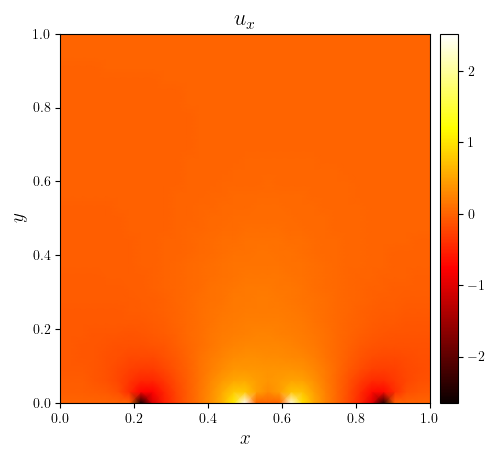

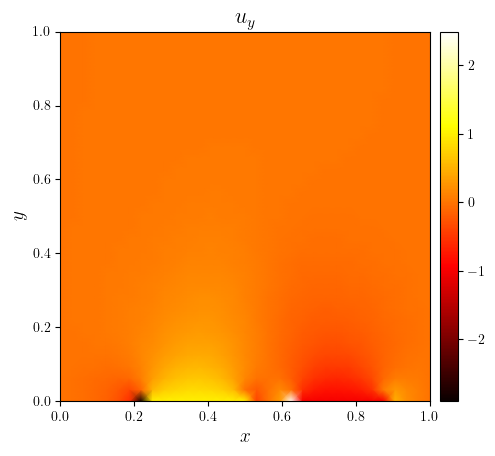

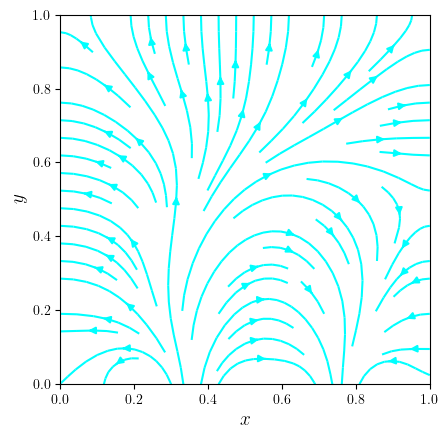

In [6]:
from lucifex.utils.fenicsx_utils import extract_component_functions
from lucifex.viz import plot_colormap, plot_streamlines, plot_quiver, save_figure


ux, uy = extract_component_functions(('P', 1), uh)

fig, ax = plot_colormap(ux, title='$u_x$', x_label='$x$', y_label='$y$')
fig, ax = plot_colormap(uy, title='$u_y$', x_label='$x$', y_label='$y$')

plot_streamlines((ux, uy ), density=0.75, color='cyan')

In [1]:
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
 
import ufl
from ufl import div, dx, inner, FiniteElement, MixedElement, FacetNormal
 
import dolfinx
import dolfinx.fem.petsc                     # explicit import required in v0.6.0
from dolfinx import fem
from dolfinx.fem import (
    Function, FunctionSpace, dirichletbc, form,
    locate_dofs_topological,
)
from dolfinx.mesh import (
    create_rectangle, CellType, GhostMode, locate_entities_boundary,
)
 
# ---------------------------------------------------------------------------
# 1.  Mesh
# ---------------------------------------------------------------------------
comm = MPI.COMM_WORLD
 
Nx, Ny = 32, 32
domain = create_rectangle(
    comm,
    [np.array([0.0, 0.0]), np.array([1.0, 1.0])],
    [Nx, Ny],
    CellType.triangle,
    GhostMode.none,
)
 
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
 
# ---------------------------------------------------------------------------
# 2.  Mark boundary facets
# ---------------------------------------------------------------------------
tol = 1e-12
x_in_lo,  x_in_hi  = 0.2, 0.5    # inflow  x-extent on y=0
x_out_lo, x_out_hi = 0.6, 0.9    # outflow x-extent on y=0
 
def inflow_facets(x):
    return (
        np.isclose(x[1], 0.0, atol=tol) &
        (x[0] >= x_in_lo  - tol) & (x[0] <= x_in_hi  + tol)
    )
 
def outflow_facets(x):
    return (
        np.isclose(x[1], 0.0, atol=tol) &
        (x[0] >= x_out_lo - tol) & (x[0] <= x_out_hi + tol)
    )
 
inflow_facet_ids  = locate_entities_boundary(domain, fdim, inflow_facets)
outflow_facet_ids = locate_entities_boundary(domain, fdim, outflow_facets)
 
# ---------------------------------------------------------------------------
# 3.  Mixed function space  W = BDM1 x DG0
# ---------------------------------------------------------------------------
cell = domain.ufl_cell()
 
BDM1 = FiniteElement("BDM", cell, 1)
DG0  = FiniteElement("DG",  cell, 0)
mel  = MixedElement([BDM1, DG0])
 
W = FunctionSpace(domain, mel)
 
# Collapsed sub-spaces (needed for BC interpolation and dof location)
V, V_to_W = W.sub(0).collapse()   # velocity sub-space + parent dof map
Q, Q_to_W = W.sub(1).collapse()   # pressure sub-space + parent dof map
 
# ---------------------------------------------------------------------------
# 4.  Heterogeneous permeability  K(x,y) = k(x,y) * I
# ---------------------------------------------------------------------------
# Interpolate into the collapsed pressure sub-space (also DG0).
k_func = Function(Q)
 
def k_expression(x):
    # Gaussian high-permeability inclusion at centre; background k = 1
    return 1.0 + 9.0 * np.exp(-((x[0] - 0.5)**2 + (x[1] - 0.5)**2) / 0.04)
 
k_func.interpolate(k_expression)
 
zero  = fem.Constant(domain, PETSc.ScalarType(0.0))
K_inv = ufl.as_matrix([
    [1.0 / k_func, zero         ],
    [zero,         1.0 / k_func ],
])
 
# ---------------------------------------------------------------------------
# 5.  Variational form on the mixed space
# ---------------------------------------------------------------------------
# ufl.split() gives sub-functions that know about the mixed structure,
# so div(u) and the block coupling work correctly in a single form.
(u, p) = ufl.TrialFunctions(W)
(v, q) = ufl.TestFunctions(W)
 
f = fem.Constant(domain, PETSc.ScalarType(0.0))
 
a = form(
      inner(K_inv * u, v) * dx
    - inner(p, div(v))    * dx
    + inner(div(u), q)    * dx
)
 
L = form(inner(f, q) * dx)
 
# ---------------------------------------------------------------------------
# 6.  Essential BCs: inflow and outflow fluxes via the velocity sub-space
# ---------------------------------------------------------------------------
# Bottom boundary outward normal: n = (0, -1)
# u.n = g  =>  u = (0, -g) on those facets.
#
# g_in_val  = -1.0  (inflow:  u.n < 0, fluid enters)
# g_out_val = +1.0  (outflow: u.n > 0, fluid leaves)
 
g_in_val  = PETSc.ScalarType(-1.0)
g_out_val = PETSc.ScalarType(+1.0)
 
# Interpolate BC values into Functions on the *collapsed* velocity space V.
u_bc_in  = Function(V)
u_bc_out = Function(V)
 
u_bc_in.interpolate(lambda x: np.vstack([
    np.zeros(x.shape[1]),
    np.full(x.shape[1], -g_in_val),
]))
 
u_bc_out.interpolate(lambda x: np.vstack([
    np.zeros(x.shape[1]),
    np.full(x.shape[1], -g_out_val),
]))
 
# locate_dofs_topological with a sub-space returns (dofs_in_W, dofs_in_V) pairs.
# The two-space overload is required when the BC value lives in the collapsed
# sub-space V but the constrained dofs belong to the mixed space W.
dofs_in  = locate_dofs_topological((W.sub(0), V), fdim, inflow_facet_ids)
dofs_out = locate_dofs_topological((W.sub(0), V), fdim, outflow_facet_ids)
 
# dirichletbc(value, dofs, sub_space) -- third argument is the sub-space
# of W on which the BC is imposed.
bc_in  = dirichletbc(u_bc_in,  dofs_in,  W.sub(0))
bc_out = dirichletbc(u_bc_out, dofs_out, W.sub(0))
 
bcs = [bc_in, bc_out]
 
# ---------------------------------------------------------------------------
# 7.  Assemble monolithic system and solve
# ---------------------------------------------------------------------------
A = dolfinx.fem.petsc.assemble_matrix(a, bcs=bcs)
A.assemble()
 
b = dolfinx.fem.petsc.assemble_vector(L)
dolfinx.fem.petsc.apply_lifting(b, [a], bcs=[bcs])
b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
fem.set_bc(b, bcs)
 
wh = Function(W)
 
ksp = PETSc.KSP().create(comm)
ksp.setOperators(A)
ksp.setType("preonly")
ksp.getPC().setType("lu")
ksp.getPC().setFactorSolverType("mumps")
ksp.setFromOptions()
ksp.solve(b, wh.vector)
wh.x.scatter_forward()
 
if comm.rank == 0:
    print(f"KSP converged reason: {ksp.getConvergedReason()}")
 
ksp.destroy(); A.destroy(); b.destroy()
 
# ---------------------------------------------------------------------------
# 8.  Extract velocity and pressure from the mixed solution
# ---------------------------------------------------------------------------
# wh.sub(i) returns a sub-Function view into W -- suitable for output.
# .collapse() gives a standalone Function in V or Q -- needed for
# operations like interpolation or passing to external routines.
 
uh = wh.sub(0).collapse()   # standalone velocity Function in V
ph = wh.sub(1).collapse()   # standalone pressure Function in Q
 
uh.name = "velocity"
ph.name = "pressure"
 
# ---------------------------------------------------------------------------
# 9.  Sanity check: net outward flux (should be ~0 when f=0)
# ---------------------------------------------------------------------------
n = FacetNormal(domain)
flux = fem.assemble_scalar(form(inner(uh, n) * ufl.ds))
print(f"Net outward flux: {flux:.6e}  (expected ~0 for f=0)")

INFO:root:running build_ext
INFO:root:building 'libffcx_forms_47cc3b5d42b0edc735a2083296c2be04aa628c1c' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_47cc3b5d42b0edc735a2083296c2be04aa628c1c.c -o ./libffcx_forms_47cc3b5d42b0edc735a2083296c2be04aa628c1c.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_47cc3b5d42b0edc735a2083296c2be04aa628c1c.o -o ./libffcx_forms_47cc3b5d42b0edc735a2083296c2be04aa628c1c.cpython-310-darwin.

KSP converged reason: 4
Net outward flux: 5.093921e-16  (expected ~0 for f=0)


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='$x$', ylabel='$y$'>)

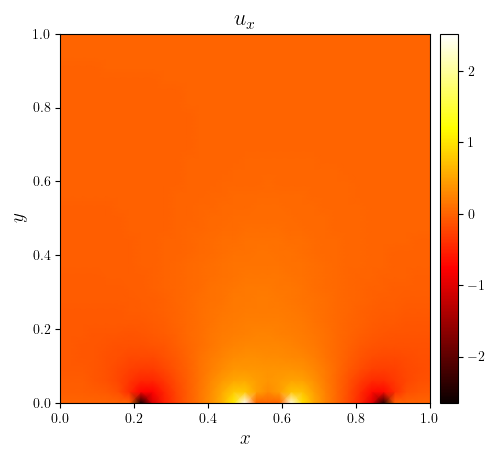

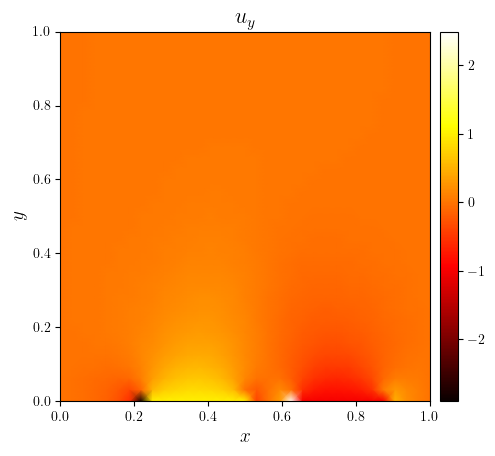

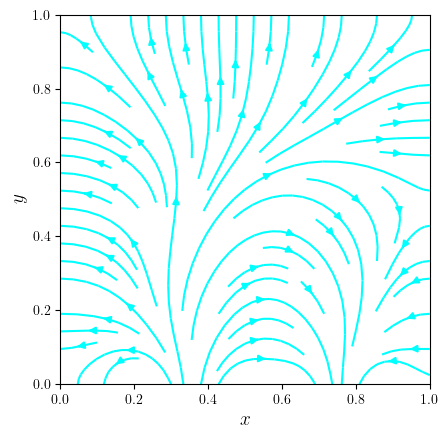

In [2]:
from lucifex.utils.fenicsx_utils import extract_component_functions
from lucifex.viz import plot_colormap, plot_streamlines, plot_quiver, save_figure


ux, uy = extract_component_functions(('P', 1), uh)

fig, ax = plot_colormap(ux, title='$u_x$', x_label='$x$', y_label='$y$')
fig, ax = plot_colormap(uy, title='$u_y$', x_label='$x$', y_label='$y$')

plot_streamlines((ux, uy ), density=0.75, color='cyan')